In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, precision_score, recall_score

In [3]:
df = pd.read_csv("../data.csv")

In [4]:
df_mod = df[:200000]
df_mod.shape

(200000, 11)

In [5]:
df_mod = pd.get_dummies(df_mod, columns=["type"])

df_mod = df_mod.drop(['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

In [6]:
df_mod.sample(3)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
7339,7,207013.89,0.0,0.0,11774234.52,15026180.08,0,False,True,False,False,False
159284,12,41983.54,0.0,0.0,857508.82,2688003.48,0,False,True,False,False,False
68466,9,35162.84,3714.0,0.0,2151144.36,2186307.20,0,False,True,False,False,False


In [7]:
df_mod.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   amount          200000 non-null  float64
 2   oldbalanceOrg   200000 non-null  float64
 3   newbalanceOrig  200000 non-null  float64
 4   oldbalanceDest  200000 non-null  float64
 5   newbalanceDest  200000 non-null  float64
 6   isFraud         200000 non-null  int64  
 7   type_CASH_IN    200000 non-null  bool   
 8   type_CASH_OUT   200000 non-null  bool   
 9   type_DEBIT      200000 non-null  bool   
 10  type_PAYMENT    200000 non-null  bool   
 11  type_TRANSFER   200000 non-null  bool   
dtypes: bool(5), float64(5), int64(2)
memory usage: 11.6 MB


In [8]:
X = df_mod.drop(['isFraud'], axis=1)

y = df_mod['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

modelo_fraude = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

modelo_fraude.fit(X_train, y_train)

print("Modelo entrenado")

Modelo entrenado


In [9]:
probabilidades = modelo_fraude.predict_proba(X_test)[:,1]
df_resultados = X_test.copy()
df_resultados['Fraude_Real'] = y_test
df_resultados['Probabilidad_Fraude'] = probabilidades
def mapear_escala_sospecha(prob):
    if prob < 0.30:
        return 'Muy Improbable'
    elif prob < 0.70:
        return 'Probable / Sospechosa'
    else:
        return 'Muy Probable'
df_resultados['Nivel_Alerta'] = df_resultados['Probabilidad_Fraude'].apply(mapear_escala_sospecha)

In [10]:
print("Dataframe procesado para el modelo de machine learing")
display(df_mod.info())
print("Dataframe con los resultados del modelo")
display(df_resultados.info())

Dataframe procesado para el modelo de machine learing
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   amount          200000 non-null  float64
 2   oldbalanceOrg   200000 non-null  float64
 3   newbalanceOrig  200000 non-null  float64
 4   oldbalanceDest  200000 non-null  float64
 5   newbalanceDest  200000 non-null  float64
 6   isFraud         200000 non-null  int64  
 7   type_CASH_IN    200000 non-null  bool   
 8   type_CASH_OUT   200000 non-null  bool   
 9   type_DEBIT      200000 non-null  bool   
 10  type_PAYMENT    200000 non-null  bool   
 11  type_TRANSFER   200000 non-null  bool   
dtypes: bool(5), float64(5), int64(2)
memory usage: 11.6 MB


None

Dataframe con los resultados del modelo
<class 'pandas.DataFrame'>
Index: 40000 entries, 185489 to 81380
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   step                 40000 non-null  int64  
 1   amount               40000 non-null  float64
 2   oldbalanceOrg        40000 non-null  float64
 3   newbalanceOrig       40000 non-null  float64
 4   oldbalanceDest       40000 non-null  float64
 5   newbalanceDest       40000 non-null  float64
 6   type_CASH_IN         40000 non-null  bool   
 7   type_CASH_OUT        40000 non-null  bool   
 8   type_DEBIT           40000 non-null  bool   
 9   type_PAYMENT         40000 non-null  bool   
 10  type_TRANSFER        40000 non-null  bool   
 11  Fraude_Real          40000 non-null  int64  
 12  Probabilidad_Fraude  40000 non-null  float64
 13  Nivel_Alerta         40000 non-null  str    
dtypes: bool(5), float64(6), int64(2), str(1)
memory usage: 3.

None

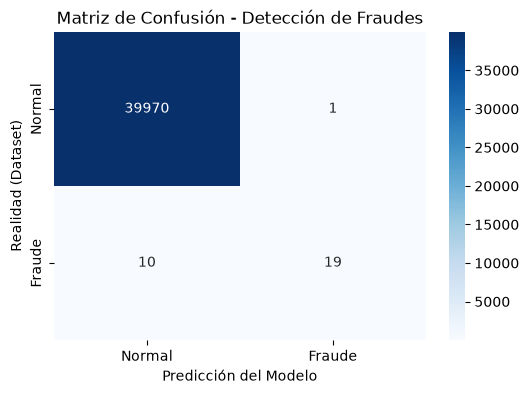

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     39971
      Fraude       0.95      0.66      0.78        29

    accuracy                           1.00     40000
   macro avg       0.97      0.83      0.89     40000
weighted avg       1.00      1.00      1.00     40000



In [11]:
# 1. Hacer las predicciones fijas (0 o 1) con el modelo entrenado
y_pred = modelo_fraude.predict(X_test)

# 2. Calcular la matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

# 3. Graficar la Matriz de Confusión para que sea entendible
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraude'],
            yticklabels=['Normal', 'Fraude'])
plt.title('Matriz de Confusión - Detección de Fraudes')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Dataset)')
plt.show()

# 4. Imprimir el reporte estadístico en texto
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraude']))

In [ ]:
print("acurracy:")
#  Accuracy: ¿Qué tan seguido acierta en general?
display(accuracy_score(y_pred=y_pred, y_true=y_test))
print("Precision:")
# Precision: Cuando el modelo grita "¡Lo encontré!", ¿qué tanto puedes confiar en él?
display(precision_score(y_pred=y_pred, y_true=y_test))
print("Recall:")
# Recall: De todo lo que había por encontrar, ¿qué porcentaje no se le escapó?
display(recall_score(y_pred=y_pred, y_true=y_test))

acurracy


0.999725

Precision


0.95

Recall


0.6551724137931034

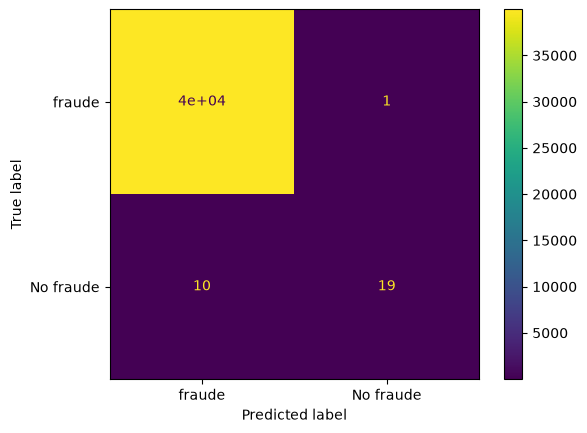

In [13]:
ConfusionMatrixDisplay.from_predictions(
y_true = y_test, y_pred = y_pred, display_labels = ["fraude",
"No fraude"]
)


In [17]:
import joblib 

joblib.dump(modelo_fraude,"../models/fraud_model.pkl")

['../models/fraud_model.pkl']